In [78]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import os
import matplotlib.pyplot as plt
import plotly.express as px
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications.resnet import ResNet101
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from IPython.display import display, Markdown
from PIL import Image
# ignore warrnings
import warnings
warnings.filterwarnings("ignore")

In [79]:
df=pd.read_csv("/kaggle/input/vehicles5/Vehicles-5/types.csv")
df.head()

,num,abk,name
0,1,car,Cars
1,2,mot,Motorcycles
2,3,pln,Planes
3,4,shp,Ships
4,5,trn,Trains


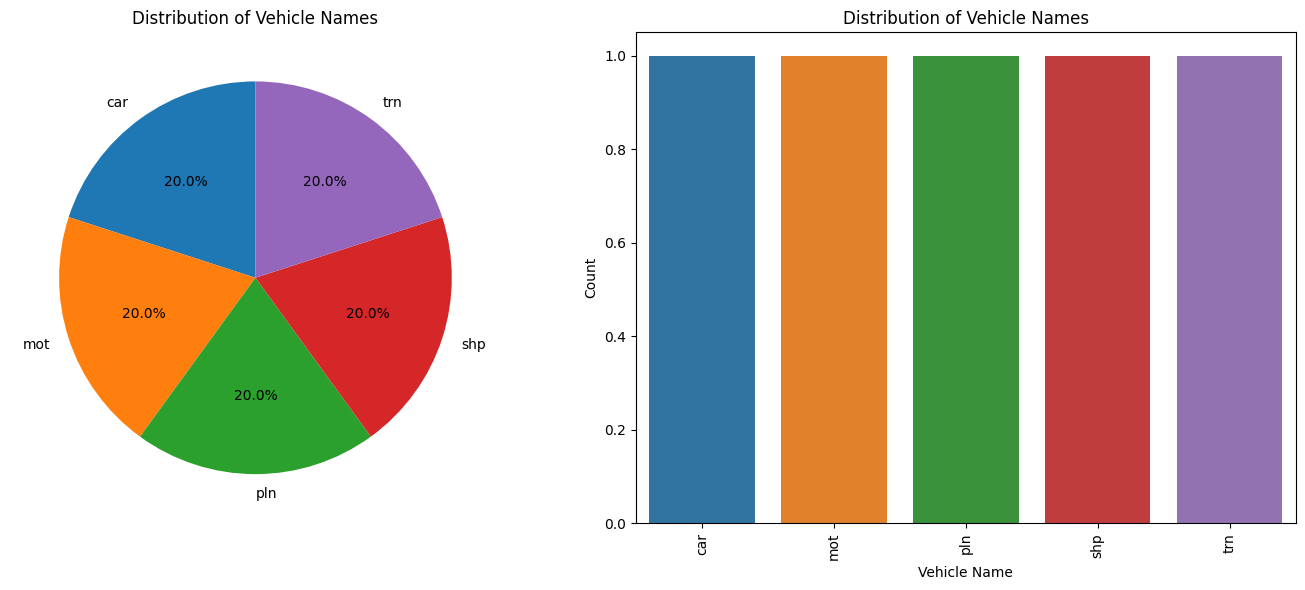

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Pie chart
df['abk'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Distribution of Vehicle Names')
axes[0].set_ylabel('')

# Bar plot
sns.countplot(x='abk', data=df, ax=axes[1])
axes[1].set_title('Distribution of Vehicle Names')
axes[1].set_xlabel('Vehicle Name')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

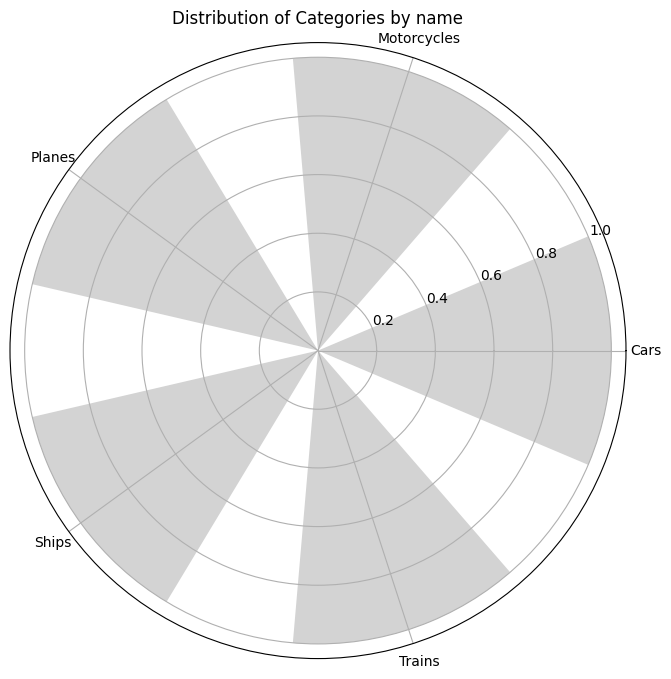

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create the radial bar chart
plt.figure(figsize=(8, 8))
labels = df['name'].unique()
values = df['name'].value_counts()
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)

plt.subplot(polar=True)
plt.bar(angles, values, width=0.8, color='lightgray')
plt.thetagrids(angles * 180 / np.pi, labels)
plt.title('Distribution of Categories by name')
plt.show()

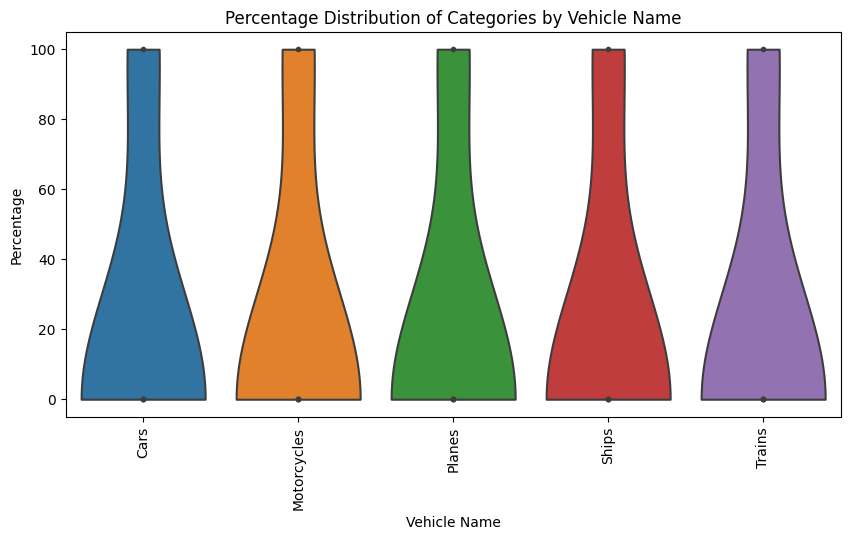

In [105]:
import pandas as pd
import matplotlib.pyplot as plt


# Group the data by common name and scientific name, and count the occurrences
category_counts = df.groupby(['num', 'name']).size().reset_index(name='count')

# Pivot the data to create the stacked bar chart format
category_counts = category_counts.pivot(index='num', columns='name', values='count').fillna(0)

# Normalize the data by calculating the percentage of each scientific name within each common name
category_percentages = category_counts.div(category_counts.sum(axis=1), axis=0) * 100

# Violin Plot
plt.figure(figsize=(10, 5))
sns.violinplot(data=category_percentages, inner="points", cut=0)
plt.title('Percentage Distribution of Categories by Vehicle Name')
plt.xlabel('Vehicle Name')
plt.ylabel('Percentage')
plt.xticks(rotation=90)
plt.show()

In [81]:
dataset_dir = '/kaggle/input/vehicles5'
print(dataset_dir)
dataset_path = '/kaggle/input/vehicles5'
print(dataset_path)

/kaggle/input/vehicles5
/kaggle/input/vehicles5


In [107]:
import os

# Define the path to your dataset directory
dataset_path = '/kaggle/input/vehicles5'

# Set the path to the train and validation folders
train_path = os.path.join(dataset_path, '/kaggle/input/vehicles5/Vehicles-5/vehicles/train')
val_path = os.path.join(dataset_path, '/kaggle/input/vehicles5/Vehicles-5/vehicles/val')
test_path = os.path.join(dataset_path, '/kaggle/input/vehicles5/Vehicles-5/vehicles/test')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [83]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Dataset directory
dataset_dir = '/kaggle/input/vehicles5'

# Define ImageDataGenerators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)  # Define test_datagen

# Create generators for train, validation, and test datasets
train_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_dir, 'Vehicles-5', 'vehicles', 'train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical')

val_generator = val_datagen.flow_from_directory(
    os.path.join(dataset_dir, 'Vehicles-5', 'vehicles', 'val'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical')

test_generator = test_datagen.flow_from_directory( 
    os.path.join(dataset_dir, 'Vehicles-5', 'vehicles', 'test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical')

Found 2794 images belonging to 5 classes.
Found 598 images belonging to 5 classes.
Found 598 images belonging to 5 classes.


In [84]:
# Get the paths to the train and val folders
train_dir = os.path.join(dataset_dir, '/kaggle/input/vehicles5/Vehicles-5/vehicles', '/kaggle/input/vehicles5/Vehicles-5/vehicles/train')
val_dir = os.path.join(dataset_dir, '/kaggle/input/vehicles5/Vehicles-5/vehicles', '/kaggle/input/vehicles5/Vehicles-5/vehicles/val')
test_dir = os.path.join(dataset_dir, '/kaggle/input/vehicles5/Vehicles-5/vehicles', '/kaggle/input/vehicles5/Vehicles-5/vehicles/test')

# Get the number of files in each folder
num_train_files = len(os.listdir(train_dir))
num_val_files = len(os.listdir(val_dir))
num_test_files = len(os.listdir(test_dir))

# Print the results
print(f"Number of files in the 'train' folder: {num_train_files}")
print(f"Number of files in the 'val' folder: {num_val_files}")
print(f"Number of files in the 'test' folder: {num_test_files}")

Number of files in the 'train' folder: 5
Number of files in the 'val' folder: 5
Number of files in the 'test' folder: 5


In [85]:
# Check the length of the training data
print(f"Training data length: {len(train_generator)}")

# Check the length of the validation data
print(f"Validation data length: {len(val_generator)}")

# Check the length of the testing data
print(f"Validation data length: {len(test_generator)}")

Training data length: 88
Validation data length: 19
Validation data length: 19


In [86]:
# Set the path to the train folder
train_path = os.path.join(dataset_path, '/kaggle/input/vehicles5/Vehicles-5/vehicles/train')

def count_images_per_folder(data_path):
    folders = os.listdir(data_path)
    folder_counts = {}
    for folder in folders:
        folder_path = os.path.join(data_path, folder)
        if os.path.isdir(folder_path):
            num_images = len(os.listdir(folder_path))
            folder_counts[folder] = num_images
    return folder_counts

# Count images per folder in training data
train_folder_counts = count_images_per_folder(train_path)
print("Number of images in each folder of Training Data:")
for folder, count in train_folder_counts.items():
    print(f"{folder}: {count} images")

Number of images in each folder of Training Data:
trn: 560 images
car: 554 images
shp: 560 images
mot: 560 images
pln: 560 images


In [87]:
# Set the path to the validation folder
val_path = os.path.join(dataset_path, '/kaggle/input/vehicles5/Vehicles-5/vehicles/val')

def count_images_per_folder(data_path):
    folders = os.listdir(data_path)
    folder_counts = {}
    for folder in folders:
        folder_path = os.path.join(data_path, folder)
        if os.path.isdir(folder_path):
            num_images = len(os.listdir(folder_path))
            folder_counts[folder] = num_images
    return folder_counts

# Count images per folder in validation data
val_folder_counts = count_images_per_folder(val_path)
print("Number of images in each folder of Validation Data:")
for folder, count in val_folder_counts.items():
    print(f"{folder}: {count} images")

Number of images in each folder of Validation Data:
trn: 120 images
car: 118 images
shp: 120 images
mot: 120 images
pln: 120 images


In [88]:
# Set the path to the validation folder
test_path = os.path.join(dataset_path, '/kaggle/input/vehicles5/Vehicles-5/vehicles/test')

def count_images_per_folder(data_path):
    folders = os.listdir(data_path)
    folder_counts = {}
    for folder in folders:
        folder_path = os.path.join(data_path, folder)
        if os.path.isdir(folder_path):
            num_images = len(os.listdir(folder_path))
            folder_counts[folder] = num_images
    return folder_counts

# Count images per folder in testing data
test_folder_counts = count_images_per_folder(test_path)
print("Number of images in each folder of Testing Data:")
for folder, count in test_folder_counts.items():
    print(f"{folder}: {count} images")

Number of images in each folder of Testing Data:
trn: 120 images
car: 118 images
shp: 120 images
mot: 120 images
pln: 120 images


First image of the Train Data:


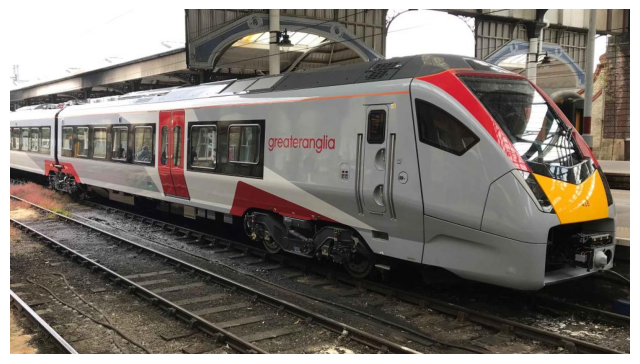

First image of the Validation Data:


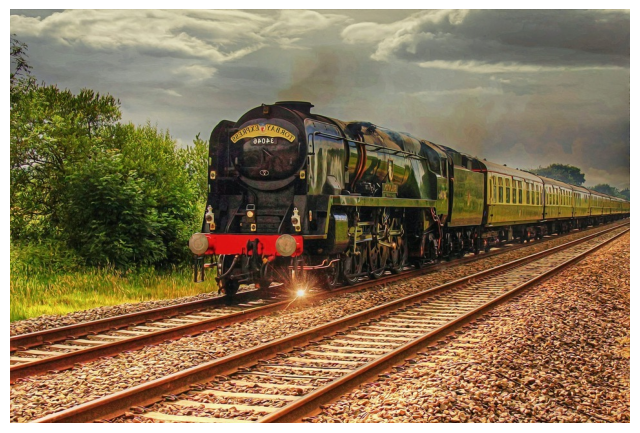

First image of the Testing Data:


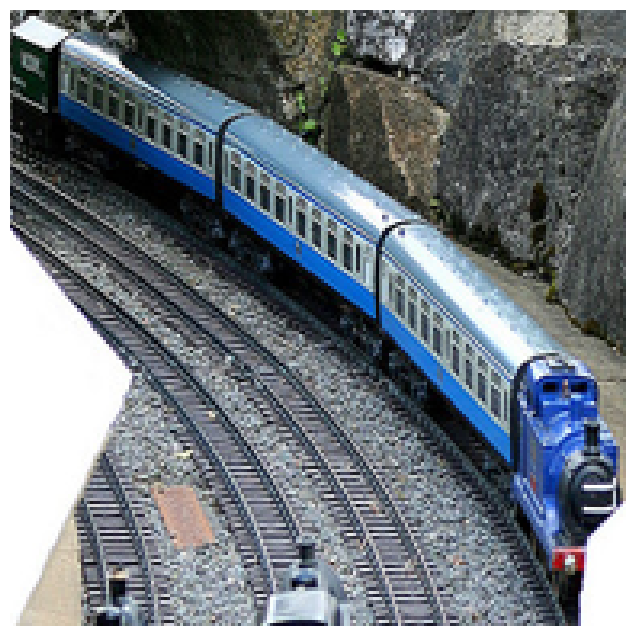

In [89]:
train_path = os.path.join(dataset_path, 'Vehicles-5', 'vehicles', 'train')
val_path = os.path.join(dataset_path, 'Vehicles-5', 'vehicles', 'val')
test_path = os.path.join(dataset_path, 'Vehicles-5', 'vehicles', 'test')

# Define a function to display an image
def display_image(image_path):
    image = Image.open(image_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

# Function to print bold text
def print_bold(text):
    print(f"\033[1m{text}\033[0m")  # \033[1m for bold, \033[0m to reset formatting

# Display the first image in the train folder
print_bold("First image of the Train Data:")
train_folders = os.listdir(train_path)
for folder in train_folders:
    folder_path = os.path.join(train_path, folder)
    image_files = os.listdir(folder_path)
    if image_files:
        image_path = os.path.join(folder_path, image_files[0])
        display_image(image_path)
        break

# Display the first image in the validation folder
print_bold("First image of the Validation Data:")
val_folders = os.listdir(val_path)
for folder in val_folders:
    folder_path = os.path.join(val_path, folder)
    image_files = os.listdir(folder_path)
    if image_files:
        image_path = os.path.join(folder_path, image_files[0])
        display_image(image_path)
        break

# Display the first image in the test folder
print_bold("First image of the Testing Data:")
test_folders = os.listdir(test_path)
for folder in test_folders:
    folder_path = os.path.join(test_path, folder)
    image_files = os.listdir(folder_path)
    if image_files:
        image_path = os.path.join(folder_path, image_files[0])
        display_image(image_path)
        break

In [ ]:
train_path = os.path.join(dataset_path, 'Vehicles-5', 'vehicles', 'train')
val_path = os.path.join(dataset_path, 'Vehicles-5', 'vehicles', 'val')
test_path = os.path.join(dataset_path, 'Vehicles-5', 'vehicles', 'test')

# Define a function to display images with titles
def display_images_with_titles(image_paths, titles):
    fig, ax = plt.subplots(2, 5, figsize=(20, 10))
    for i, image_path in enumerate(image_paths):
        row = i // 5
        col = i % 5
        image = Image.open(image_path)
        ax[row, col].imshow(image)
        ax[row, col].axis('off')
        ax[row, col].set_title(titles[i])
    plt.tight_layout()
    plt.show()

# Function to print bold text
def print_bold(text):
    print(f"\033[1m{text}\033[0m")  # \033[1m for bold, \033[0m to reset formatting

# Display the first ten images in the train folder with folder names
print_bold("First 10 Folder Images of Training Data:")
train_folders = os.listdir(train_path)
train_images_displayed = 0
train_image_paths = []
train_image_titles = []
for folder in train_folders:
    folder_path = os.path.join(train_path, folder)
    image_files = os.listdir(folder_path)
    for i, image_file in enumerate(image_files):
        if train_images_displayed < 10:
            image_path = os.path.join(folder_path, image_file)
            train_image_paths.append(image_path)
            train_image_titles.append(f"Folder: {folder}")
            train_images_displayed += 1
        else:
            break
display_images_with_titles(train_image_paths, train_image_titles)

# Display the first ten images in the validation folder with folder names
print_bold("First 10 Folder Images of Validation Data:")
val_folders = os.listdir(val_path)
val_images_displayed = 0
val_image_paths = []
val_image_titles = []
for folder in val_folders:
    folder_path = os.path.join(val_path, folder)
    image_files = os.listdir(folder_path)
    for i, image_file in enumerate(image_files):
        if val_images_displayed < 10:
            image_path = os.path.join(folder_path, image_file)
            val_image_paths.append(image_path)
            val_image_titles.append(f"Folder: {folder}")
            val_images_displayed += 1
        else:
            break
display_images_with_titles(val_image_paths, val_image_titles)

# Display the first ten images in the test folder with folder names
print_bold("First 10 Folder Images of Test Data:")
test_folders = os.listdir(test_path)
test_images_displayed = 0
test_image_paths = []
test_image_titles = []
for folder in test_folders:
    folder_path = os.path.join(test_path, folder)
    image_files = os.listdir(folder_path)
    for i, image_file in enumerate(image_files):
        if test_images_displayed < 10:
            image_path = os.path.join(folder_path, image_file)
            test_image_paths.append(image_path)
            test_image_titles.append(f"Folder: {folder}")
            test_images_displayed += 1
        else:
            break
display_images_with_titles(test_image_paths, test_image_titles)

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Define the path to your dataset directory
dataset_path = '/kaggle/input/vehicles5/Vehicles-5'

# Set the path to the train and validation folders
train_path = os.path.join(dataset_path, 'vehicles', 'train')
val_path = os.path.join(dataset_path, 'vehicles', 'val')
test_path = os.path.join(dataset_path, 'vehicles', 'test')

# Define a function to display images with titles
def display_images_with_titles(image_paths, titles):
    fig, ax = plt.subplots(2, 5, figsize=(20, 10))
    for i, image_path in enumerate(image_paths):
        row = i // 5
        col = i % 5
        image = Image.open(image_path)
        ax[row, col].imshow(image)
        ax[row, col].axis('off')
        ax[row, col].set_title(titles[i])
    plt.tight_layout()
    plt.show()

# Function to print bold text
def print_bold(text):
    print(f"\033[1m{text}\033[0m")  # \033[1m for bold, \033[0m to reset formatting

print_bold("\nNext 10 Images of Training Data:")
train_images_displayed = 0
train_image_paths = []
train_image_titles = []
start_index = 20  # Start collecting images from the 21st image onwards
for folder in train_folders:
    folder_path = os.path.join(train_path, folder)
    image_files = os.listdir(folder_path)
    for image_file in image_files:
        if train_images_displayed >= start_index and train_images_displayed < start_index + 10:  # Collect next 10 images
            image_path = os.path.join(folder_path, image_file)
            train_image_paths.append(image_path)
            train_image_titles.append(f"Folder: {folder}")
        train_images_displayed += 1
        if train_images_displayed >= start_index + 10:  # Stop collecting after 10 images
            break
    if train_images_displayed >= start_index + 10:
        break

display_images_with_titles(train_image_paths, train_image_titles)

print_bold("\nNext 10 Images of Validation Data:")
val_images_displayed = 0
val_image_paths = []
val_image_titles = []
for folder in val_folders:
    folder_path = os.path.join(val_path, folder)
    image_files = os.listdir(folder_path)
    for image_file in image_files:
        if val_images_displayed >= start_index and val_images_displayed < start_index + 10:  # Collect next 10 images
            image_path = os.path.join(folder_path, image_file)
            val_image_paths.append(image_path)
            val_image_titles.append(f"Folder: {folder}")
        val_images_displayed += 1
        if val_images_displayed >= start_index + 10:  # Stop collecting after 10 images
            break
    if val_images_displayed >= start_index + 10:
        break

display_images_with_titles(val_image_paths, val_image_titles)

print_bold("\nNext 10 Images of Test Data:")
test_images_displayed = 0
test_image_paths = []
test_image_titles = []
for folder in test_folders:
    folder_path = os.path.join(test_path, folder)
    image_files = os.listdir(folder_path)
    for image_file in image_files:
        if test_images_displayed >= start_index and test_images_displayed < start_index + 10:  # Collect next 10 images
            image_path = os.path.join(folder_path, image_file)
            test_image_paths.append(image_path)
            test_image_titles.append(f"Folder: {folder}")
        test_images_displayed += 1
        if test_images_displayed >= start_index + 10:  # Stop collecting after 10 images
            break
    if test_images_displayed >= start_index + 10:
        break

display_images_with_titles(test_image_paths, test_image_titles)

In [ ]:
# Define a function to display images with titles
def display_images_with_titles(image_paths, titles):
    num_images = len(image_paths)
    num_rows = (num_images - 1) // 5 + 1  # Calculate number of rows needed
    fig, ax = plt.subplots(num_rows, 5, figsize=(20, 4 * num_rows))  # Adjust figsize based on number of rows
    for i in range(num_images):
        row = i // 5
        col = i % 5
        image = Image.open(image_paths[i])
        ax[row, col].imshow(image)
        ax[row, col].axis('off')
        ax[row, col].set_title(titles[i])
    plt.tight_layout()
    plt.show()


# Function to fetch images and titles
def fetch_images_and_titles(data_path, num_images):
    folders = os.listdir(data_path)
    images_displayed = 0
    image_paths = []
    image_titles = []
    start_index = max(0, len(folders) - 10)  # Start from the last 10 folders

    for folder in folders[start_index:]:
        folder_path = os.path.join(data_path, folder)
        image_files = os.listdir(folder_path)
        for image_file in image_files:
            if images_displayed < num_images:
                image_path = os.path.join(folder_path, image_file)
                image_paths.append(image_path)
                image_titles.append(f"Folder: {folder}")
                images_displayed += 1
            else:
                break
        if images_displayed >= num_images:
            break
    
    return image_paths, image_titles

# Fetch images and titles for training and validation datasets
train_image_paths, train_image_titles = fetch_images_and_titles(train_path, 30)
val_image_paths, val_image_titles = fetch_images_and_titles(val_path, 30)
test_image_paths, test_image_titles = fetch_images_and_titles(test_path, 30)

# Display the Markdown headings with bold formatting
display(Markdown("**Images of Last 10 Folders of Training Data:**"))
display_images_with_titles(train_image_paths, train_image_titles)

display(Markdown("**Images of Last 10 Folders of Validation Data:**"))
display_images_with_titles(val_image_paths, val_image_titles)

display(Markdown("**Images of Last 10 Folders of Test Data:**"))
display_images_with_titles(test_image_paths, test_image_titles)

In [ ]:
# Function to display an image
def display_image(image_path, title):
    image = Image.open(image_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis('off')
    plt.title(title)
    plt.show()

# Function to print bold headings
def print_bold_heading(heading):
    print(f"\n \033[1m{heading}:\033[0m")

# Display images from 5 folders in the train folder
print_bold_heading("Images of each Folder of Training Data:")
train_folders = os.listdir(train_path)
fig, ax = plt.subplots(1, 5, figsize=(20, 10))  # 1 row and 5 columns
for i, folder in enumerate(train_folders[:5]):  # Only take the first 5 folders
    folder_path = os.path.join(train_path, folder)
    image_files = os.listdir(folder_path)
    for j, image_file in enumerate(image_files[:1]):  # Display one image per folder
        image_path = os.path.join(folder_path, image_file)
        ax[i].imshow(Image.open(image_path))
        ax[i].axis('off')
        ax[i].set_title(f"Folder: {folder}")
plt.show()

# Display images from 5 folders in the validation folder
print_bold_heading("Images of each folder of Validation Data:")
val_folders = os.listdir(val_path)
fig, ax = plt.subplots(1, 5, figsize=(20, 10))  # 1 row and 5 columns
for i, folder in enumerate(val_folders[:5]):  # Only take the first 5 folders
    folder_path = os.path.join(val_path, folder)
    image_files = os.listdir(folder_path)
    for j, image_file in enumerate(image_files[:1]):  # Display one image per folder
        image_path = os.path.join(folder_path, image_file)
        ax[i].imshow(Image.open(image_path))
        ax[i].axis('off')
        ax[i].set_title(f"Folder: {folder}")
plt.show()

# Display images from 5 folders in the test folder
print_bold_heading("Images of each folder of Test Data:")
test_folders = os.listdir(test_path)
fig, ax = plt.subplots(1, 5, figsize=(20, 10))  # 1 row and 5 columns
for i, folder in enumerate(test_folders[:5]):  # Only take the first 5 folders
    folder_path = os.path.join(test_path, folder)
    image_files = os.listdir(folder_path)
    for j, image_file in enumerate(image_files[:1]):  # Display one image per folder
        image_path = os.path.join(folder_path, image_file)
        ax[i].imshow(Image.open(image_path))
        ax[i].axis('off')
        ax[i].set_title(f"Folder: {folder}")
plt.show()

In [ ]:
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Load species CSV
df = pd.read_csv('/kaggle/input/vehicles5/Vehicles-5/types.csv')

# Ensure the 'name' column is used as the category for training
# For example, using 'name' as the target classes
df['name'] = df['name'].astype(str)  # Ensure it's treated as a string

# Define image generators for training and validation
train_datagen = ImageDataGenerator(rescale=1./255,
                                  rotation_range=20,
                                  width_shift_range=0.2,
                                  height_shift_range=0.2,
                                  shear_range=0.2,
                                  zoom_range=0.2,
                                  horizontal_flip=True,
                                  vertical_flip=True,
                                  brightness_range=[0.5, 1.5])

train_generator = train_datagen.flow_from_directory(
        '/kaggle/input/vehicles5/Vehicles-5/vehicles/train',
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical')  # Ensure class_mode is categorical

val_datagen = ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_directory(
        '/kaggle/input/vehicles5/Vehicles-5/vehicles/val',
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical')  # Ensure class_mode is categorical

# Load pre-trained VGG16 model without the top (fully connected) layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Unfreeze some layers in the base model
for layer in base_model.layers[:15]:
    layer.trainable = False
for layer in base_model.layers[15:]:
    layer.trainable = True

# Build the model on top of the base model
num_classes = len(df['name'].unique())  # Get the number of unique categories in 'name'

model = Sequential([
    base_model,
    Dense(512, activation='relu'),
    Dense(num_classes, activation='softmax')  # Number of output neurons matches unique categories
])

# Compile the model with Adam optimizer
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Compute class weights to handle class imbalance (using 'name' column for the target)
class_weights = df['name'].value_counts().sort_index().to_dict()

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train the model with early stopping
history = model.fit(
      train_generator,
      steps_per_epoch=int(train_generator.samples/train_generator.batch_size),
      epochs=50,
      validation_data=val_generator,
      validation_steps=int(val_generator.samples/val_generator.batch_size),
      callbacks=[early_stopping],
      class_weight=class_weights)  # Use class weights for handling imbalance

# Evaluate the model
loss, accuracy = model.evaluate(val_generator)
print("Validation Accuracy:", accuracy)

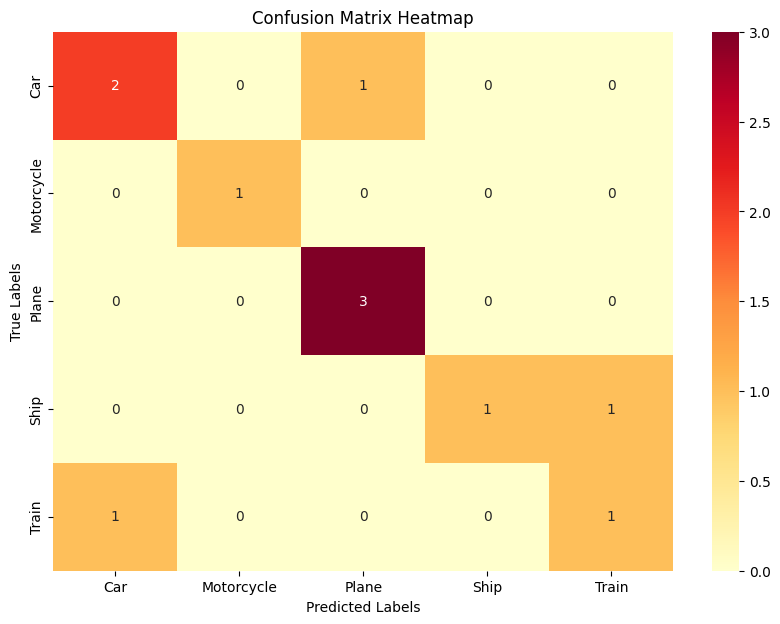

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# Example data: true labels and predicted labels
true_labels = ['Car', 'Car', 'Plane', 'Train', 'Train', 'Plane', 'Car', 'Ship', 'Ship', 'Plane', 'Motorcycle']
predicted_labels = ['Car', 'Plane', 'Plane', 'Train', 'Car', 'Plane', 'Car', 'Ship', 'Train', 'Plane', 'Motorcycle']

# Generate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels, labels=np.unique(true_labels))

# Convert to a DataFrame for better readability
labels = np.unique(true_labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# Plot the heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm_df, annot=True, cmap='YlOrRd', fmt='d', cbar=True)

# Add labels and title
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

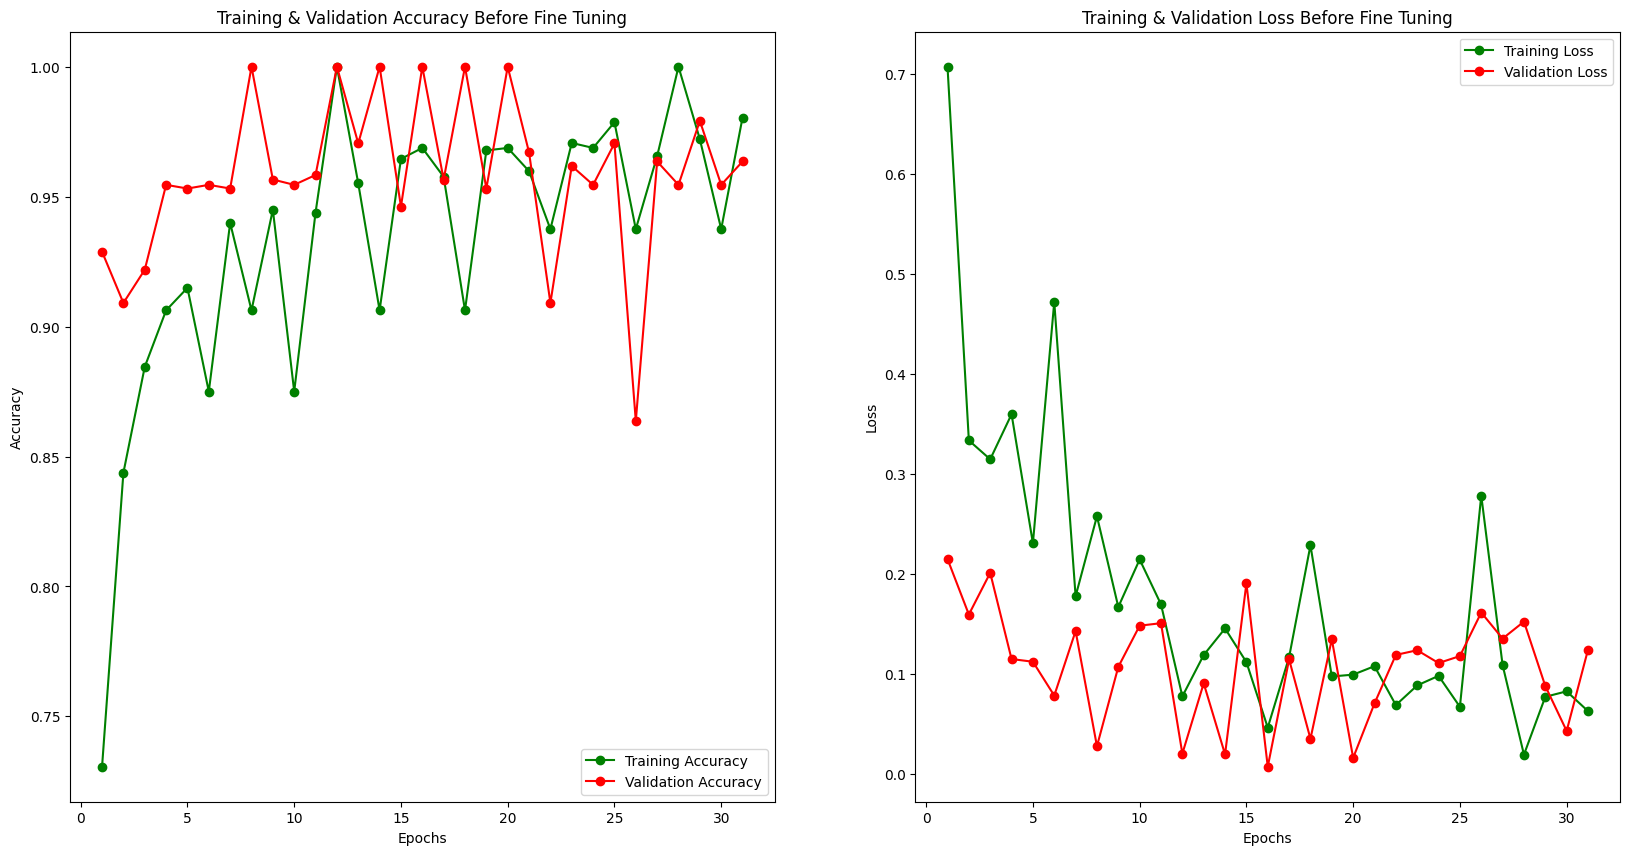

In [103]:
import matplotlib.pyplot as plt

# Create Accuracy and Loss chart function
def plot_accuracy_loss_chart(history):
    epochs = range(1, len(history.history['accuracy']) + 1)  # Adjust epochs based on actual length of history
    fig , ax = plt.subplots(1, 2)
    
    # Retrieve training and validation accuracy/loss from history
    train_acc = history.history['accuracy']
    train_loss = history.history['loss']
    val_acc = history.history['val_accuracy']
    val_loss = history.history['val_loss']
    
    fig.set_size_inches(20, 10)
    
    # Plot Accuracy
    ax[0].plot(epochs, train_acc, 'go-', label='Training Accuracy')
    ax[0].plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    ax[0].set_title('Training & Validation Accuracy Before Fine Tuning')
    ax[0].legend()
    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("Accuracy")

    # Plot Loss
    ax[1].plot(epochs, train_loss, 'g-o', label='Training Loss')
    ax[1].plot(epochs, val_loss, 'r-o', label='Validation Loss')
    ax[1].set_title('Training & Validation Loss Before Fine Tuning')
    ax[1].legend()
    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("Loss")
    
    plt.show()

# Call the function with the correct history
plot_accuracy_loss_chart(history)  # Use the history object from the first code

Found 2794 images belonging to 5 classes.
Found 598 images belonging to 5 classes.
Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 61s 609ms/step - accuracy: 0.5824 - loss: 1.0758 - val_accuracy: 0.9288 - val_loss: 0.2151
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8438 - loss: 0.3337 - val_accuracy: 0.9091 - val_loss: 0.1595
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 57s 613ms/step - accuracy: 0.8870 - loss: 0.3062 - val_accuracy: 0.9219 - val_loss: 0.2012
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9062 - loss: 0.3599 - val_accuracy: 0.9545 - val_loss: 0.1150
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 58s 609ms/step - accuracy: 0.9145 - loss: 0.2385 - val_accuracy: 0.9531 - val_loss: 0.1123
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8750 - loss: 0.4723 - val_accuracy: 0.9545 - val_loss: 0.0784
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 58s 622ms/step - accuracy: 0.9420 - loss: 0.1768 - val_accuracy: 0.9531 - val_loss: 0.1430
Epoch 8/50
87/87 ━━━━━━

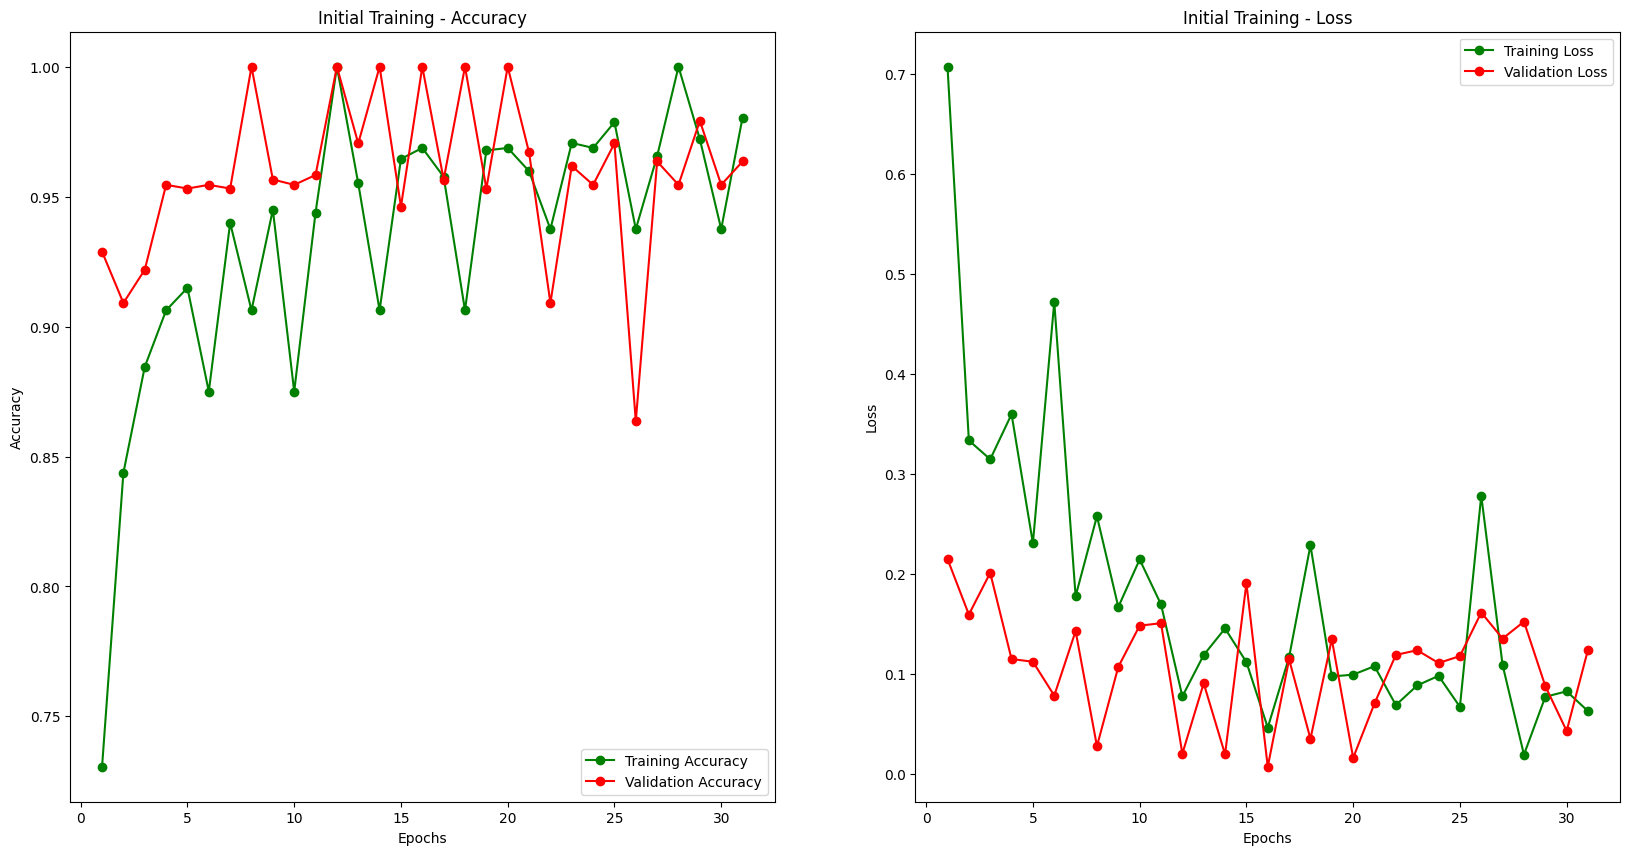

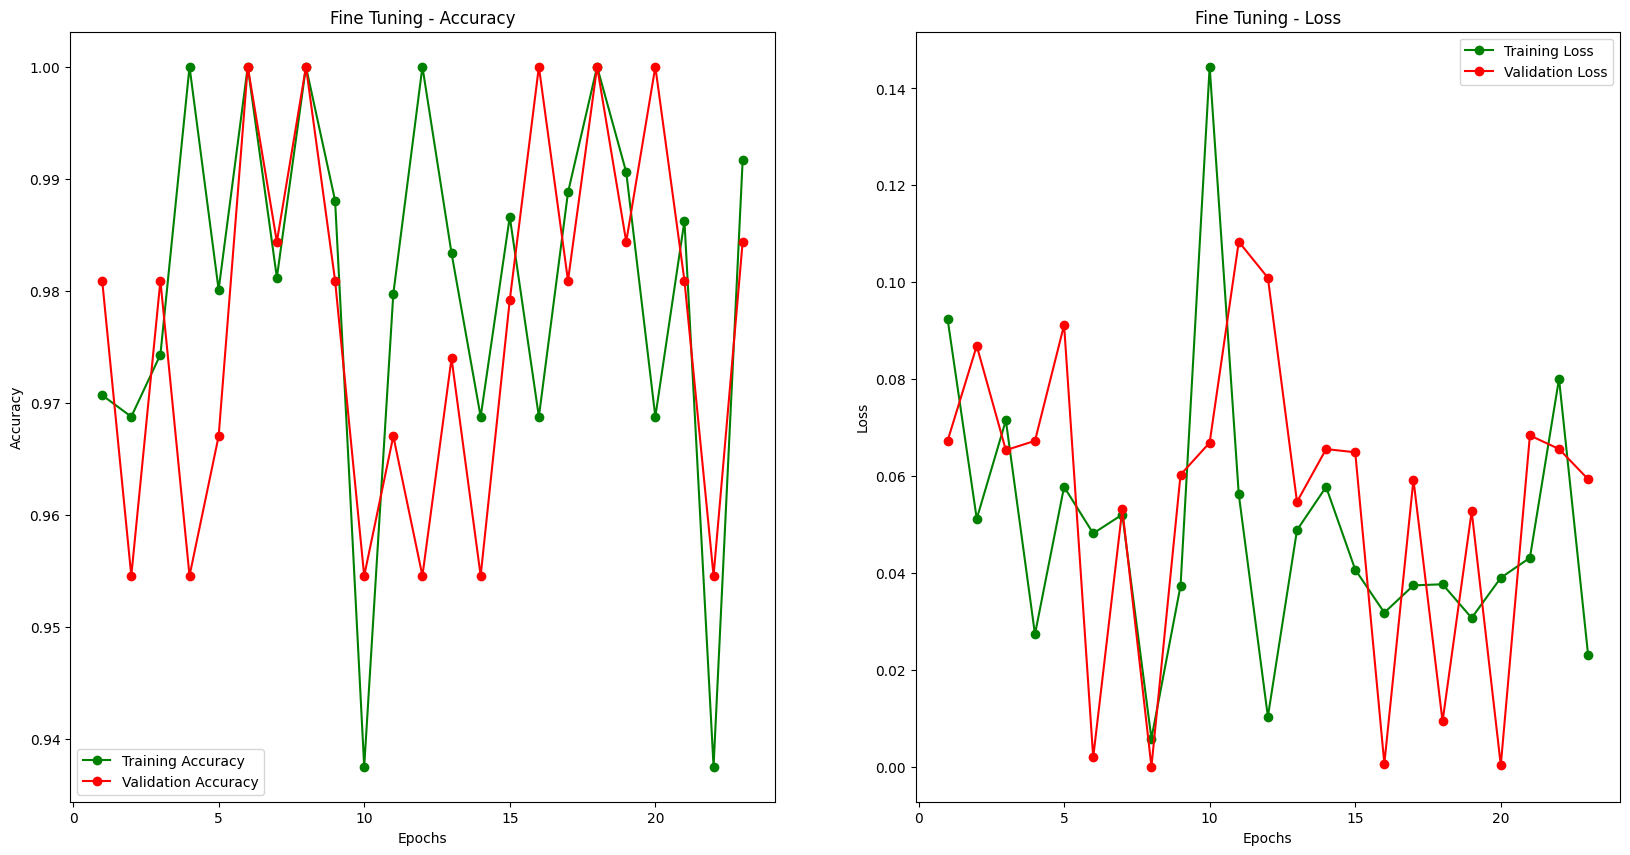

In [90]:
import os
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load species CSV
df = pd.read_csv('/kaggle/input/vehicles5/Vehicles-5/types.csv')

# Ensure the 'name' column is used as the category for training
df['name'] = df['name'].astype(str)

# Define image generators for training and validation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.5, 1.5]
)

train_generator = train_datagen.flow_from_directory(
    '/kaggle/input/vehicles5/Vehicles-5/vehicles/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_datagen = ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_directory(
    '/kaggle/input/vehicles5/Vehicles-5/vehicles/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Load pre-trained VGG16 model without the top (fully connected) layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the initial layers for feature extraction
for layer in base_model.layers[:15]:
    layer.trainable = False
for layer in base_model.layers[15:]:
    layer.trainable = True

# Build the model on top of the base model
num_classes = len(df['name'].unique())  # Get the number of unique categories in 'name'

model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dense(num_classes, activation='softmax')  # Number of output neurons matches unique categories
])

# Compile the model with Adam optimizer
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Compute class weights to handle class imbalance
class_weights = df['name'].value_counts().sort_index().to_dict()

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train the model with initial frozen layers
history = model.fit(
    train_generator,
    steps_per_epoch=int(train_generator.samples/train_generator.batch_size),
    epochs=50,
    validation_data=val_generator,
    validation_steps=int(val_generator.samples/val_generator.batch_size),
    callbacks=[early_stopping],
    class_weight=class_weights
)

# Fine-tuning begins here
for layer in base_model.layers:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tuning_history = model.fit(
    train_generator,
    steps_per_epoch=int(train_generator.samples/train_generator.batch_size),
    epochs=50,
    validation_data=val_generator,
    validation_steps=int(val_generator.samples/val_generator.batch_size),
    callbacks=[early_stopping],
    class_weight=class_weights
)

# Evaluate the fine-tuned model
fine_tuned_loss, fine_tuned_accuracy = model.evaluate(val_generator)
print("Fine-tuned Validation Accuracy:", fine_tuned_accuracy)

# Updated Graph Function
def plot_accuracy_loss_chart(history, title):
    epochs = range(1, len(history.history['accuracy']) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
    
    # Accuracy
    train_acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    ax[0].plot(epochs, train_acc, 'go-', label='Training Accuracy')
    ax[0].plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    ax[0].set_title(f'{title} - Accuracy')
    ax[0].legend()
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Accuracy')

    # Loss
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    ax[1].plot(epochs, train_loss, 'g-o', label='Training Loss')
    ax[1].plot(epochs, val_loss, 'r-o', label='Validation Loss')
    ax[1].set_title(f'{title} - Loss')
    ax[1].legend()
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Loss')

    plt.show()

# Plot results
plot_accuracy_loss_chart(history, "Initial Training")
plot_accuracy_loss_chart(fine_tuning_history, "Fine Tuning")

In [91]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 512)                 │      12,845,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 5)                   │           2,565 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 82,688,465 (315.43 MB)

 Trainable params: 27,562,821 (105.14 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 55,125,644 (210.29 MB)

In [76]:
!pip install gradio

In [97]:
model.save('/kaggle/working/Vehicles_class.h5')

In [100]:
import os
print(os.path.exists('/kaggle/working/Vehicles_class.h5'))

True


In [108]:
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image
from tensorflow.keras.applications.vgg16 import preprocess_input

# Load the trained model
try:
    model = tf.keras.models.load_model('/kaggle/working/Vehicles_class.h5')
    print("Model loaded successfully!")
except Exception as e:
    print("Error loading model:", e)

# Class labels
class_names = ["car", "motorcycle", "plane", "ship", "train"]

# Preprocessing function
def preprocess_image(image):
    image = image.resize((224, 224))  # Resize to match model input
    image = np.array(image)  # Convert to numpy array
    image = preprocess_input(image)  # Use model-specific preprocessing
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    return image

# Prediction function
def predict_vehicle(image):
    processed_image = preprocess_image(image)
    predictions = model.predict(processed_image)  # Predict
    predicted_class = class_names[np.argmax(predictions)]  # Get predicted label
    confidence = np.max(predictions) * 100  # Get confidence score
    return f"{predicted_class} ({confidence:.2f}%)"

# Gradio interface
interface = gr.Interface(
    fn=predict_vehicle,
    inputs=gr.Image(type="pil", label="Upload Vehicle Image"),
    outputs="text",
    title="AInspire Vehicle Type Classification",
    description="Upload an image of a vehicle to classify it into its category."
)

# Launch the interface
interface.launch(share=True)


Error loading model: Exception encountered when calling Flatten.call().

'list' object has no attribute 'shape'

Arguments received by Flatten.call():
  • args=(['<KerasTensor shape=(None, 7, 7, 512), dtype=float32, sparse=False, name=keras_tensor_1510>'],)
  • kwargs=<class 'inspect._empty'>
* Running on local URL:  http://127.0.0.1:7873
* Running on public URL: https://3b877ae8ce00c8e041.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
